# Bayesian Spatial Models: A Pedagogical Walkthrough

This notebook demonstrates all five models currently implemented in `bayespecon`:

1. SLX
2. SAR
3. SEM
4. SDM
5. SDEM

Each section explains the model idea, fits the model, and inspects posterior summaries and spatial effects.

## Conceptual Roadmap

Let $W$ denote the spatial weights matrix and $WX$ the spatial lag of covariates.

- **SLX**: $y = X\beta + WX\theta + \epsilon$
- **SAR**: $y = \rho Wy + X\beta + \epsilon$
- **SEM**: $y = X\beta + u$, $u = \lambda Wu + \epsilon$
- **SDM**: $y = \rho Wy + X\beta + WX\theta + \epsilon$
- **SDEM**: $y = X\beta + WX\theta + u$, $u = \lambda Wu + \epsilon$

In `bayespecon`, all models accept either:
- formula mode: `model_class(formula=..., data=..., W=...)`, or
- matrix mode: `model_class(y=..., X=..., W=...)`.

In [1]:
import pathlib
import sys

import arviz as az
import geodatasets
import geopandas as gpd
import numpy as np
import pandas as pd
from IPython.display import display
from libpysal.graph import Graph

# Ensure local package import works when running from notebooks/
repo_root = pathlib.Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from bayespecon import SLX, SAR, SEM, SDM, SDEM

az.style.use("arviz-white")

In [2]:
# Load sample spatial dataset
gdf = gpd.read_file(geodatasets.data.geoda.airbnb.url)
xcols = ["poverty", "rev_rating", "num_spots", "crowded"]
ycol = "price_pp"
gdf = gdf.dropna(subset=xcols + [ycol]).copy()

# Build contiguity graph (queen)
W = Graph.build_contiguity(gdf, rook=False).transform('r')

print(f"Observations: {len(gdf)}")
print(f"Predictors: {xcols}")

Observations: 67
Predictors: ['poverty', 'rev_rating', 'num_spots', 'crowded']


## Helper Functions

To keep each model section focused, we use utility functions to:
- fit with consistent MCMC settings,
- print posterior summaries,
- tabulate direct/indirect/total effects.

For a quick pedagogical run, we use small draw counts. Increase these for real inference.

In [ ]:
def fit_and_report(model_cls, formula, data, W, draws=400, tune=400, chains=4, seed=42):
    model = model_cls(
        formula=formula,
        data=data,
        W=W,
        logdet_method="eigenvalue",
    )

    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=0.9,
        random_seed=seed,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )

    summary = model.summary(round_to=3)
    effects = model.spatial_effects()
    effects_df = pd.DataFrame({
        "feature": effects["feature_names"],
        "direct": effects["direct"],
        "indirect": effects["indirect"],
        "total": effects["total"],
    })

    return model, idata, summary, effects_df

## Convergence Diagnostics Helper

For each fitted model, we will inspect:
- `r_hat` (target close to 1.00)
- effective sample sizes (`ess_bulk`, `ess_tail`)
- trace plots for key parameters.

In [4]:
import matplotlib.pyplot as plt


def diagnostics_table(idata, var_names):
    cols = ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]
    return az.summary(idata, var_names=var_names, round_to=3)[cols]


def show_trace(idata, var_names, title):
    az.plot_trace(idata, var_names=var_names)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

## 1) SLX: Spatially Lagged Covariates Only

Model:

$$
y = X\beta + WX\theta + \epsilon
$$

Interpretation:
- `beta` captures local covariate effects.
- `theta` captures neighbor-covariate spillovers.
- No spatial lag on $y$, so no autoregressive propagation through outcomes.

In [5]:
slx, idata_slx, summary_slx, effects_slx = fit_and_report(
    SLX,
    formula="price_pp ~ poverty + rev_rating + num_spots + crowded",
    data=gdf,
    W=W,
)
display(summary_slx)
display(effects_slx)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]
Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 5 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,180.136,209.343,-215.269,559.031,8.400,5.739,621.908,790.783,1.004
poverty,-0.681,0.447,-1.532,0.139,0.015,0.011,955.187,992.294,1.002
rev_rating,0.353,0.896,-1.458,1.898,0.031,0.020,829.149,1053.888,1.005
num_spots,0.020,0.031,-0.040,0.076,0.001,0.001,811.391,917.977,1.005
crowded,-0.956,1.117,-3.079,1.167,0.034,0.026,1070.128,1235.667,1.000
W*poverty,1.213,0.662,-0.050,2.393,0.024,0.016,785.120,1103.832,1.002
W*rev_rating,-1.671,1.794,-4.907,1.793,0.066,0.045,736.233,903.638,1.002
W*num_spots,0.202,0.048,0.117,0.294,0.002,0.001,868.913,1044.155,1.003
W*crowded,-1.613,1.650,-4.731,1.432,0.060,0.040,766.650,896.467,1.003
sigma,23.601,1.996,20.006,27.260,0.051,0.058,1465.707,1243.136,1.000


,feature,direct,indirect,total
0,poverty,-0.680787,0.018101,-0.662686
1,rev_rating,0.353139,-0.024935,0.328205
2,num_spots,0.019847,0.003011,0.022858
3,crowded,-0.956494,-0.024075,-0.980569


,mean,sd,ess_bulk,ess_tail,r_hat
beta[Intercept],180.136,209.343,621.908,790.783,1.004
beta[poverty],-0.681,0.447,955.187,992.294,1.002
beta[rev_rating],0.353,0.896,829.149,1053.888,1.005
beta[num_spots],0.020,0.031,811.391,917.977,1.005
beta[crowded],-0.956,1.117,1070.128,1235.667,1.000
beta[W*poverty],1.213,0.662,785.120,1103.832,1.002
beta[W*rev_rating],-1.671,1.794,736.233,903.638,1.002
beta[W*num_spots],0.202,0.048,868.913,1044.155,1.003
beta[W*crowded],-1.613,1.650,766.650,896.467,1.003
sigma,23.601,1.996,1465.707,1243.136,1.000


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_21366/3308626596.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


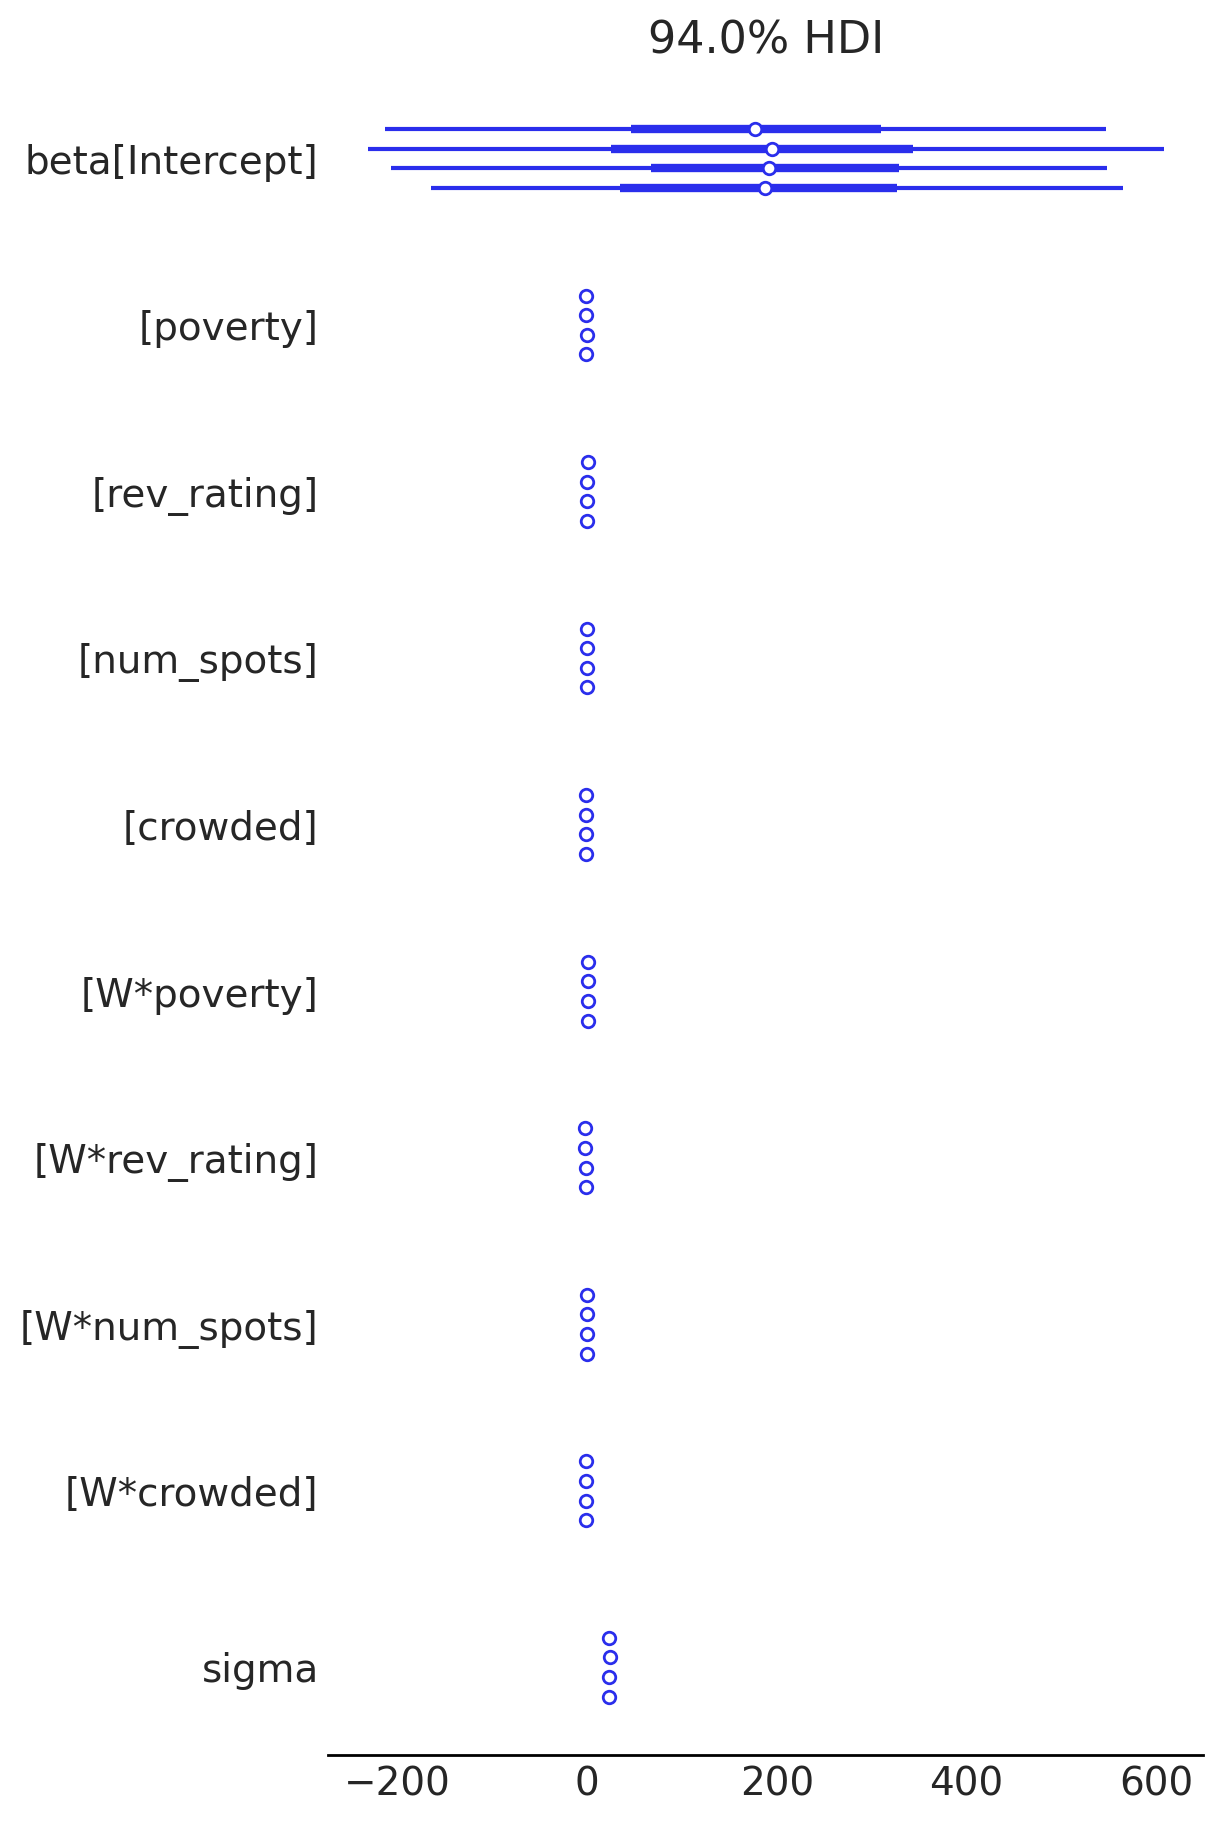

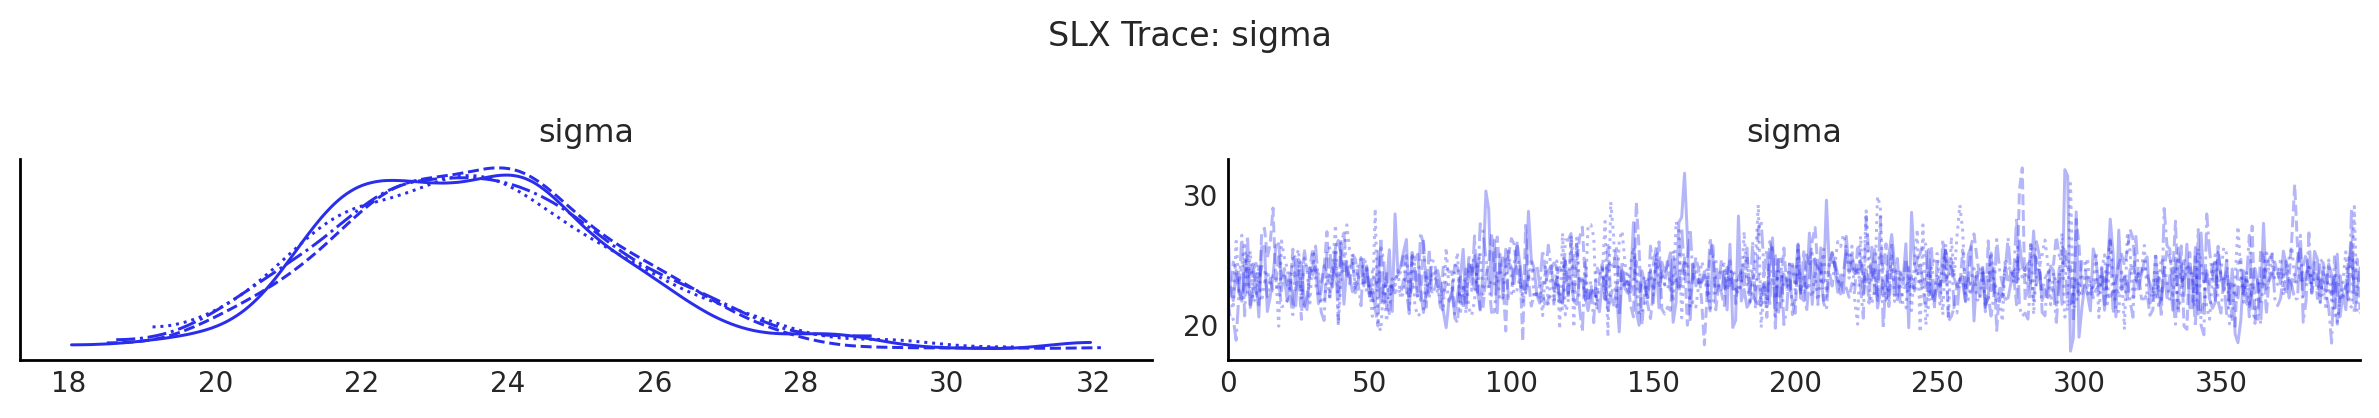

In [6]:
az.plot_forest(idata_slx)
display(diagnostics_table(idata_slx, ["beta", "sigma"]))
show_trace(idata_slx, ["sigma"], "SLX Trace: sigma")

## 2) SAR: Spatial Lag of Outcome

Model:

$$
y = \rho Wy + X\beta + \epsilon
$$

Interpretation:
- $\rho$ controls feedback from neighboring outcomes.
- Effects are amplified through $(I - \rho W)^{-1}$, so direct and indirect impacts differ from raw $\beta$.

In [7]:
sar, idata_sar, summary_sar, effects_sar = fit_and_report(
    SAR,
    formula="price_pp ~ poverty + rev_rating + num_spots + crowded",
    data=gdf,
    W=W,
)
display(summary_sar)
display(effects_sar)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]
Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 12 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-40.373,81.202,-199.727,102.046,3.088,2.403,688.698,604.223,1.006
poverty,0.105,0.323,-0.529,0.692,0.011,0.008,874.712,778.188,1.003
rev_rating,0.875,0.850,-0.635,2.488,0.033,0.024,675.750,739.338,1.006
num_spots,0.078,0.025,0.032,0.125,0.001,0.001,903.257,1155.566,1.008
crowded,-1.742,0.881,-3.253,-0.007,0.026,0.022,1156.658,944.109,1.001
rho,0.438,0.139,0.197,0.717,0.005,0.003,882.407,1039.872,1.002
sigma,24.382,2.161,20.489,28.219,0.063,0.065,1223.648,992.276,1.001


,feature,direct,indirect,total
0,Intercept,-42.513397,41.440401,-1.072996
1,poverty,0.110284,-0.107501,0.002783
2,rev_rating,0.921414,-0.898159,0.023256
3,num_spots,0.081899,-0.079832,0.002067
4,crowded,-1.833933,1.787647,-0.046287


,mean,sd,ess_bulk,ess_tail,r_hat
rho,0.438,0.139,882.407,1039.872,1.002
beta[Intercept],-40.373,81.202,688.698,604.223,1.006
beta[poverty],0.105,0.323,874.712,778.188,1.003
beta[rev_rating],0.875,0.850,675.750,739.338,1.006
beta[num_spots],0.078,0.025,903.257,1155.566,1.008
beta[crowded],-1.742,0.881,1156.658,944.109,1.001
sigma,24.382,2.161,1223.648,992.276,1.001


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_21366/3308626596.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


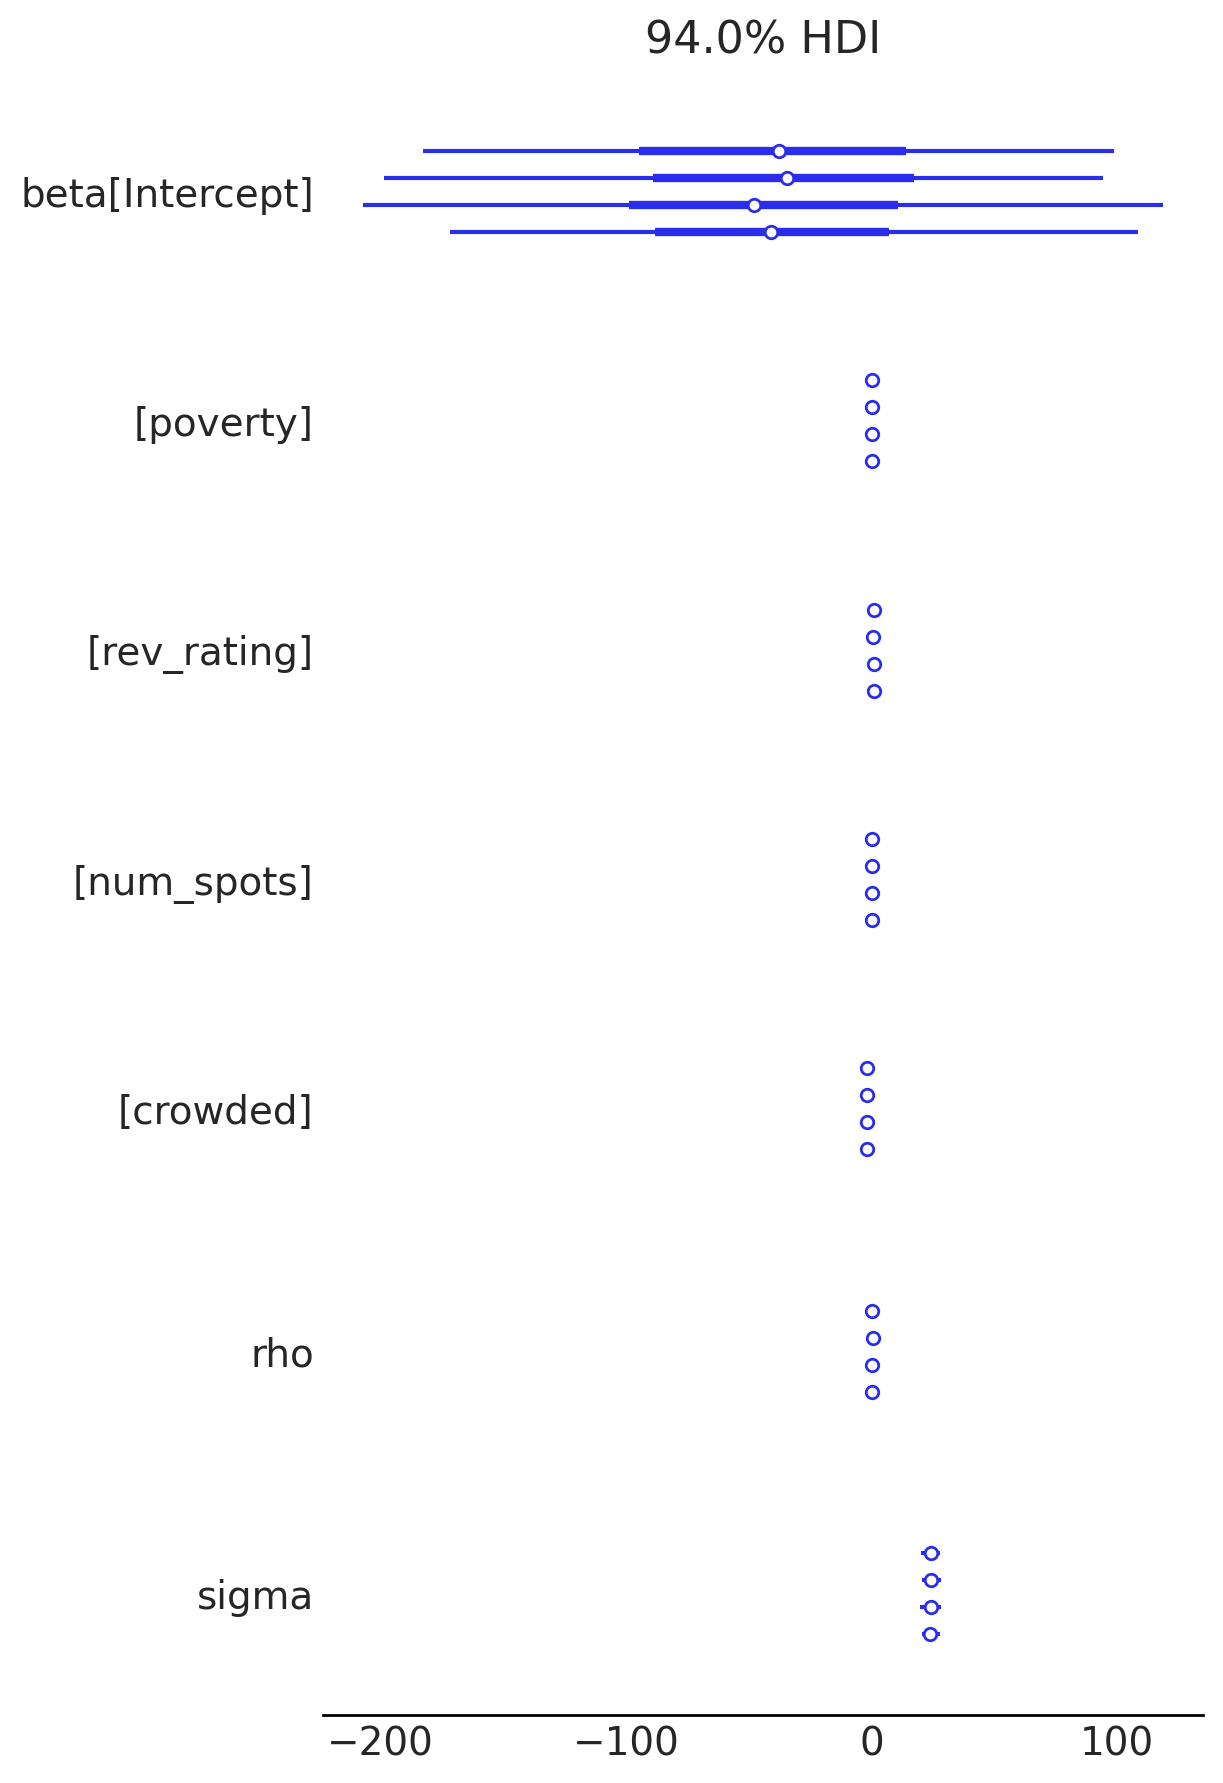

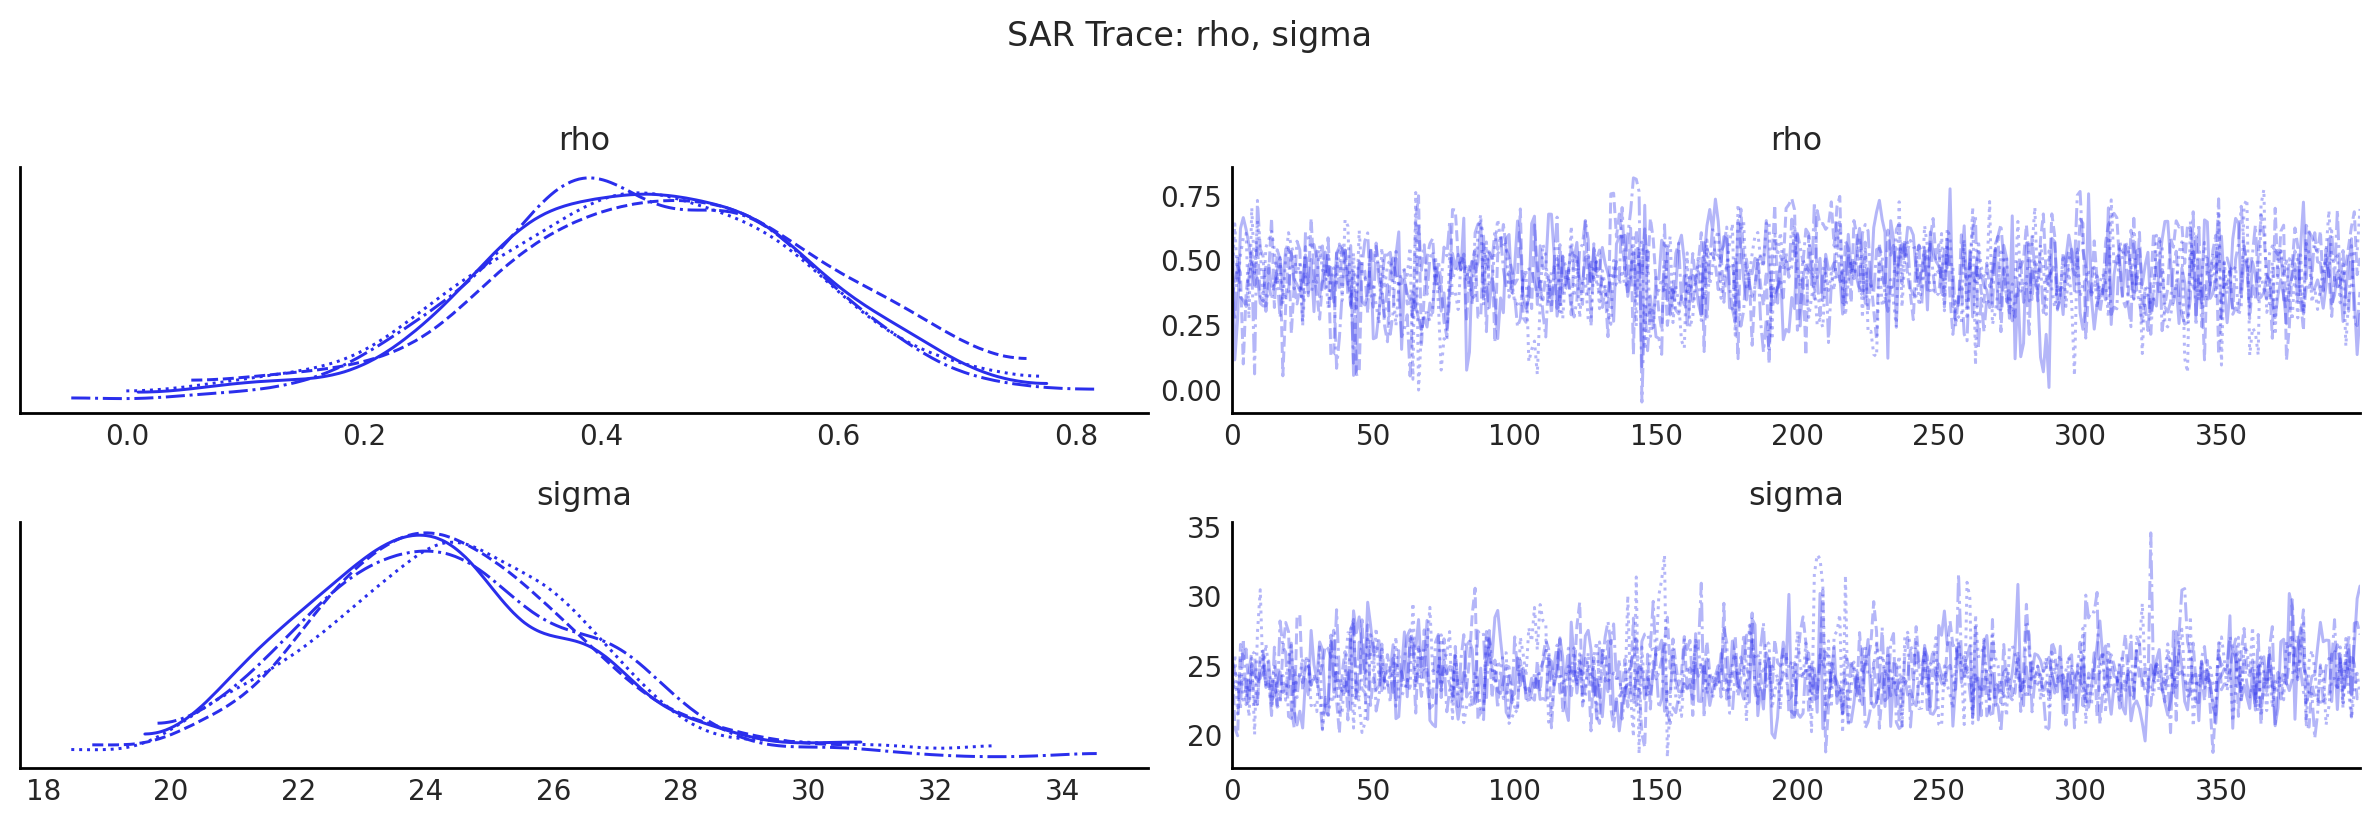

In [8]:
az.plot_forest(idata_sar)
display(diagnostics_table(idata_sar, ["rho", "beta", "sigma"]))
show_trace(idata_sar, ["rho", "sigma"], "SAR Trace: rho, sigma")

## 3) SEM: Spatial Correlation in Errors

Model:

$$
y = X\beta + u, \quad u = \lambda Wu + \epsilon
$$

Interpretation:
- Spatial dependence is moved to latent shocks rather than outcome feedback.
- Useful when omitted spatial factors induce correlated residuals.

In [9]:
sem, idata_sem, summary_sem, effects_sem = fit_and_report(
    SEM,
    formula="price_pp ~ poverty + rev_rating + num_spots + crowded",
    data=gdf,
    W=W,
)
display(summary_sem)
display(effects_sem)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam, beta, sigma]
Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 7 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-32.764,75.885,-177.422,104.514,2.862,2.040,692.708,815.882,1.002
poverty,-0.147,0.454,-0.944,0.734,0.016,0.011,759.805,983.367,1.001
rev_rating,1.187,0.804,-0.250,2.772,0.030,0.021,711.347,815.160,1.002
num_spots,0.069,0.033,0.006,0.129,0.001,0.001,776.438,1146.115,1.002
crowded,-1.796,1.134,-3.851,0.371,0.034,0.031,1096.591,993.432,1.002
lam,0.525,0.172,0.177,0.804,0.007,0.004,652.495,874.537,1.001
sigma,24.963,2.271,20.865,29.504,0.073,0.073,998.118,860.226,1.002


,feature,direct,indirect,total
0,Intercept,-32.763641,0.0,-32.763641
1,poverty,-0.147493,0.0,-0.147493
2,rev_rating,1.186864,0.0,1.186864
3,num_spots,0.069380,0.0,0.069380
4,crowded,-1.796192,0.0,-1.796192


,mean,sd,ess_bulk,ess_tail,r_hat
lam,0.525,0.172,652.495,874.537,1.001
beta[Intercept],-32.764,75.885,692.708,815.882,1.002
beta[poverty],-0.147,0.454,759.805,983.367,1.001
beta[rev_rating],1.187,0.804,711.347,815.160,1.002
beta[num_spots],0.069,0.033,776.438,1146.115,1.002
beta[crowded],-1.796,1.134,1096.591,993.432,1.002
sigma,24.963,2.271,998.118,860.226,1.002


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_21366/3308626596.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


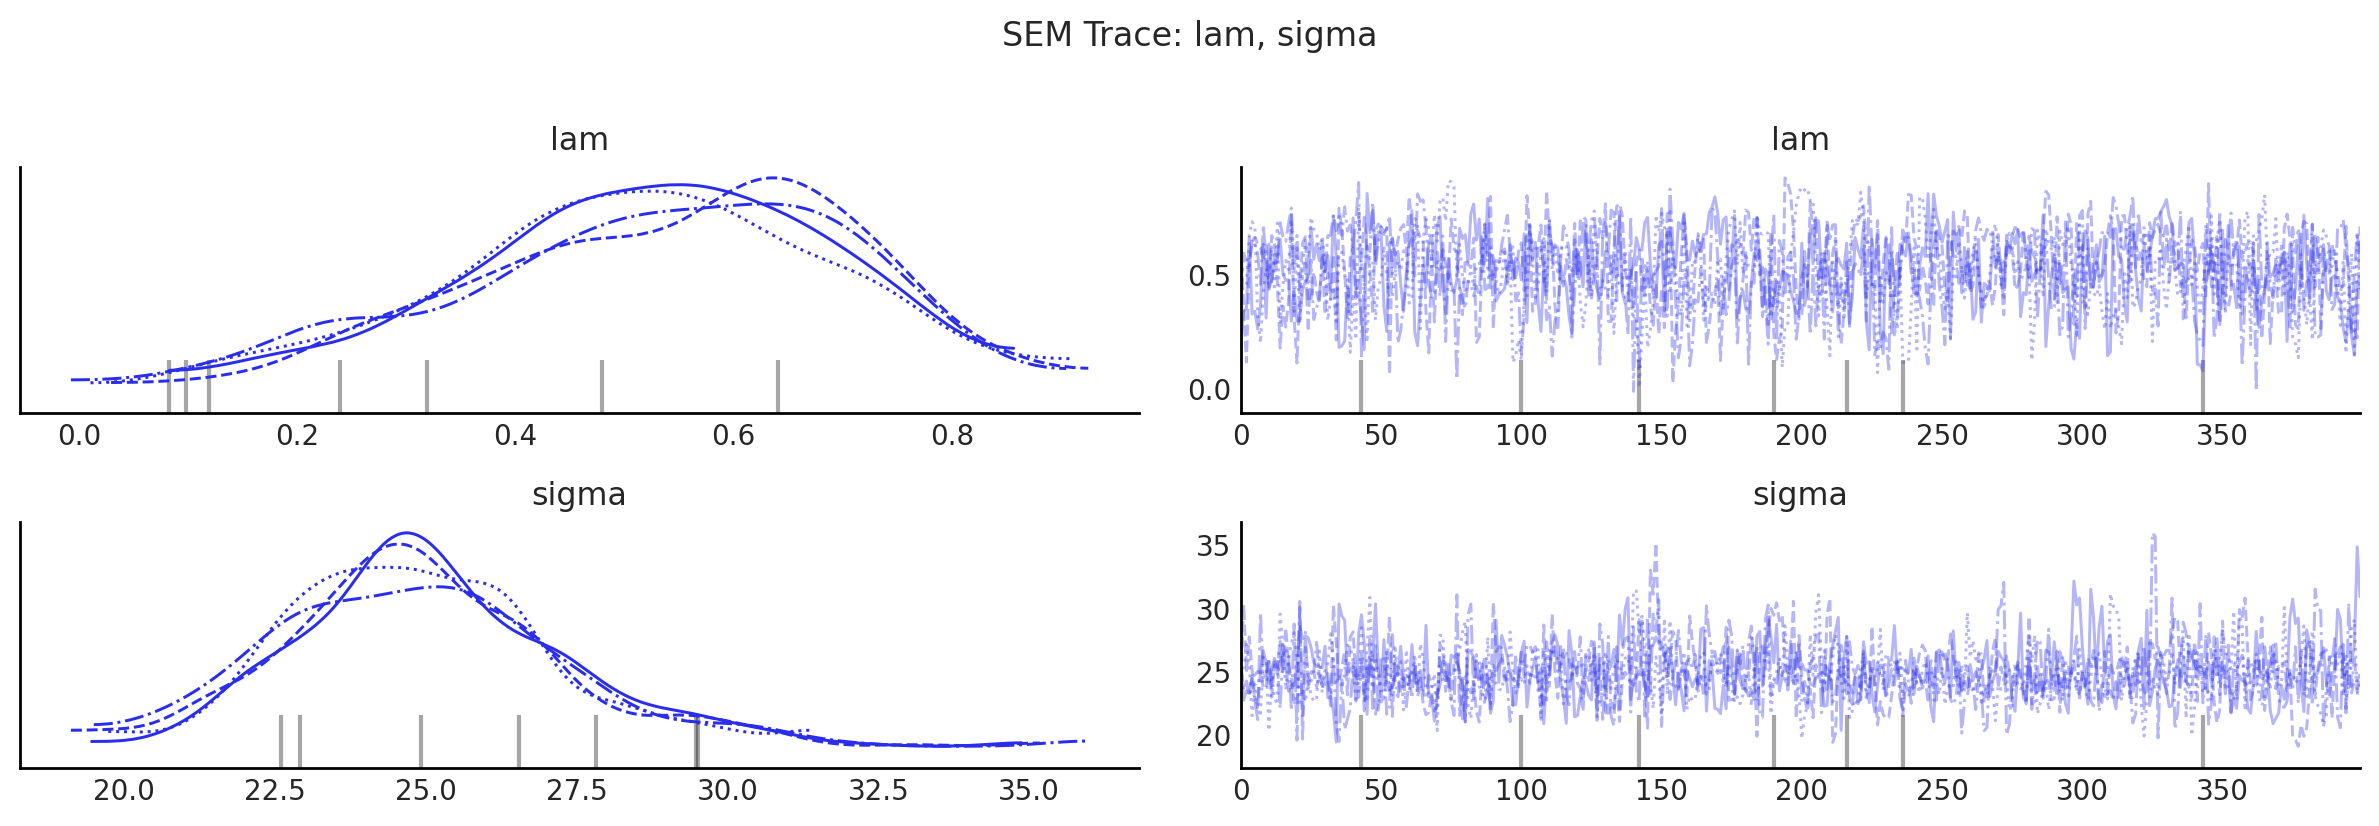

In [10]:
display(diagnostics_table(idata_sem, ["lam", "beta", "sigma"]))
show_trace(idata_sem, ["lam", "sigma"], "SEM Trace: lam, sigma")

## 4) SDM: SAR + SLX

Model:

$$
y = \rho Wy + X\beta + WX\theta + \epsilon
$$

Interpretation:
- Includes both outcome feedback and neighbor-covariate channels.
- Often used as a flexible nesting model for SAR/SLX.

In [11]:
sdm, idata_sdm, summary_sdm, effects_sdm = fit_and_report(
    SDM,
    formula="price_pp ~ poverty + rev_rating + num_spots + crowded",
    data=gdf,
    W=W,
)
display(summary_sdm)
display(effects_sdm)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]
Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 28 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,192.920,208.361,-166.996,614.896,7.464,6.638,780.697,978.974,1.005
poverty,-0.685,0.462,-1.585,0.128,0.016,0.010,841.573,1135.857,1.002
rev_rating,0.447,0.914,-1.299,2.152,0.028,0.023,1049.106,979.929,1.003
num_spots,0.016,0.031,-0.038,0.077,0.001,0.001,1099.128,1056.609,1.000
crowded,-1.037,1.149,-3.316,0.996,0.037,0.027,970.971,1064.626,1.001
W*poverty,1.021,0.686,-0.223,2.269,0.024,0.016,784.149,1059.430,1.003
W*rev_rating,-2.046,1.816,-5.238,1.515,0.061,0.048,891.934,1037.072,1.004
W*num_spots,0.166,0.052,0.068,0.266,0.002,0.001,943.187,922.597,1.002
W*crowded,-0.938,1.733,-4.023,2.408,0.061,0.043,823.143,1008.630,1.003
rho,0.238,0.167,-0.084,0.537,0.005,0.004,1004.402,800.572,1.004


,feature,direct,indirect,total
0,poverty,-0.636198,0.642759,0.006561
1,rev_rating,0.335078,-0.366405,-0.031327
2,num_spots,0.026257,-0.022681,0.003576
3,crowded,-1.105435,1.066752,-0.038683


,mean,sd,ess_bulk,ess_tail,r_hat
rho,0.238,0.167,1004.402,800.572,1.004
beta[Intercept],192.920,208.361,780.697,978.974,1.005
beta[poverty],-0.685,0.462,841.573,1135.857,1.002
beta[rev_rating],0.447,0.914,1049.106,979.929,1.003
beta[num_spots],0.016,0.031,1099.128,1056.609,1.000
beta[crowded],-1.037,1.149,970.971,1064.626,1.001
beta[W*poverty],1.021,0.686,784.149,1059.430,1.003
beta[W*rev_rating],-2.046,1.816,891.934,1037.072,1.004
beta[W*num_spots],0.166,0.052,943.187,922.597,1.002
beta[W*crowded],-0.938,1.733,823.143,1008.630,1.003


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_21366/3308626596.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


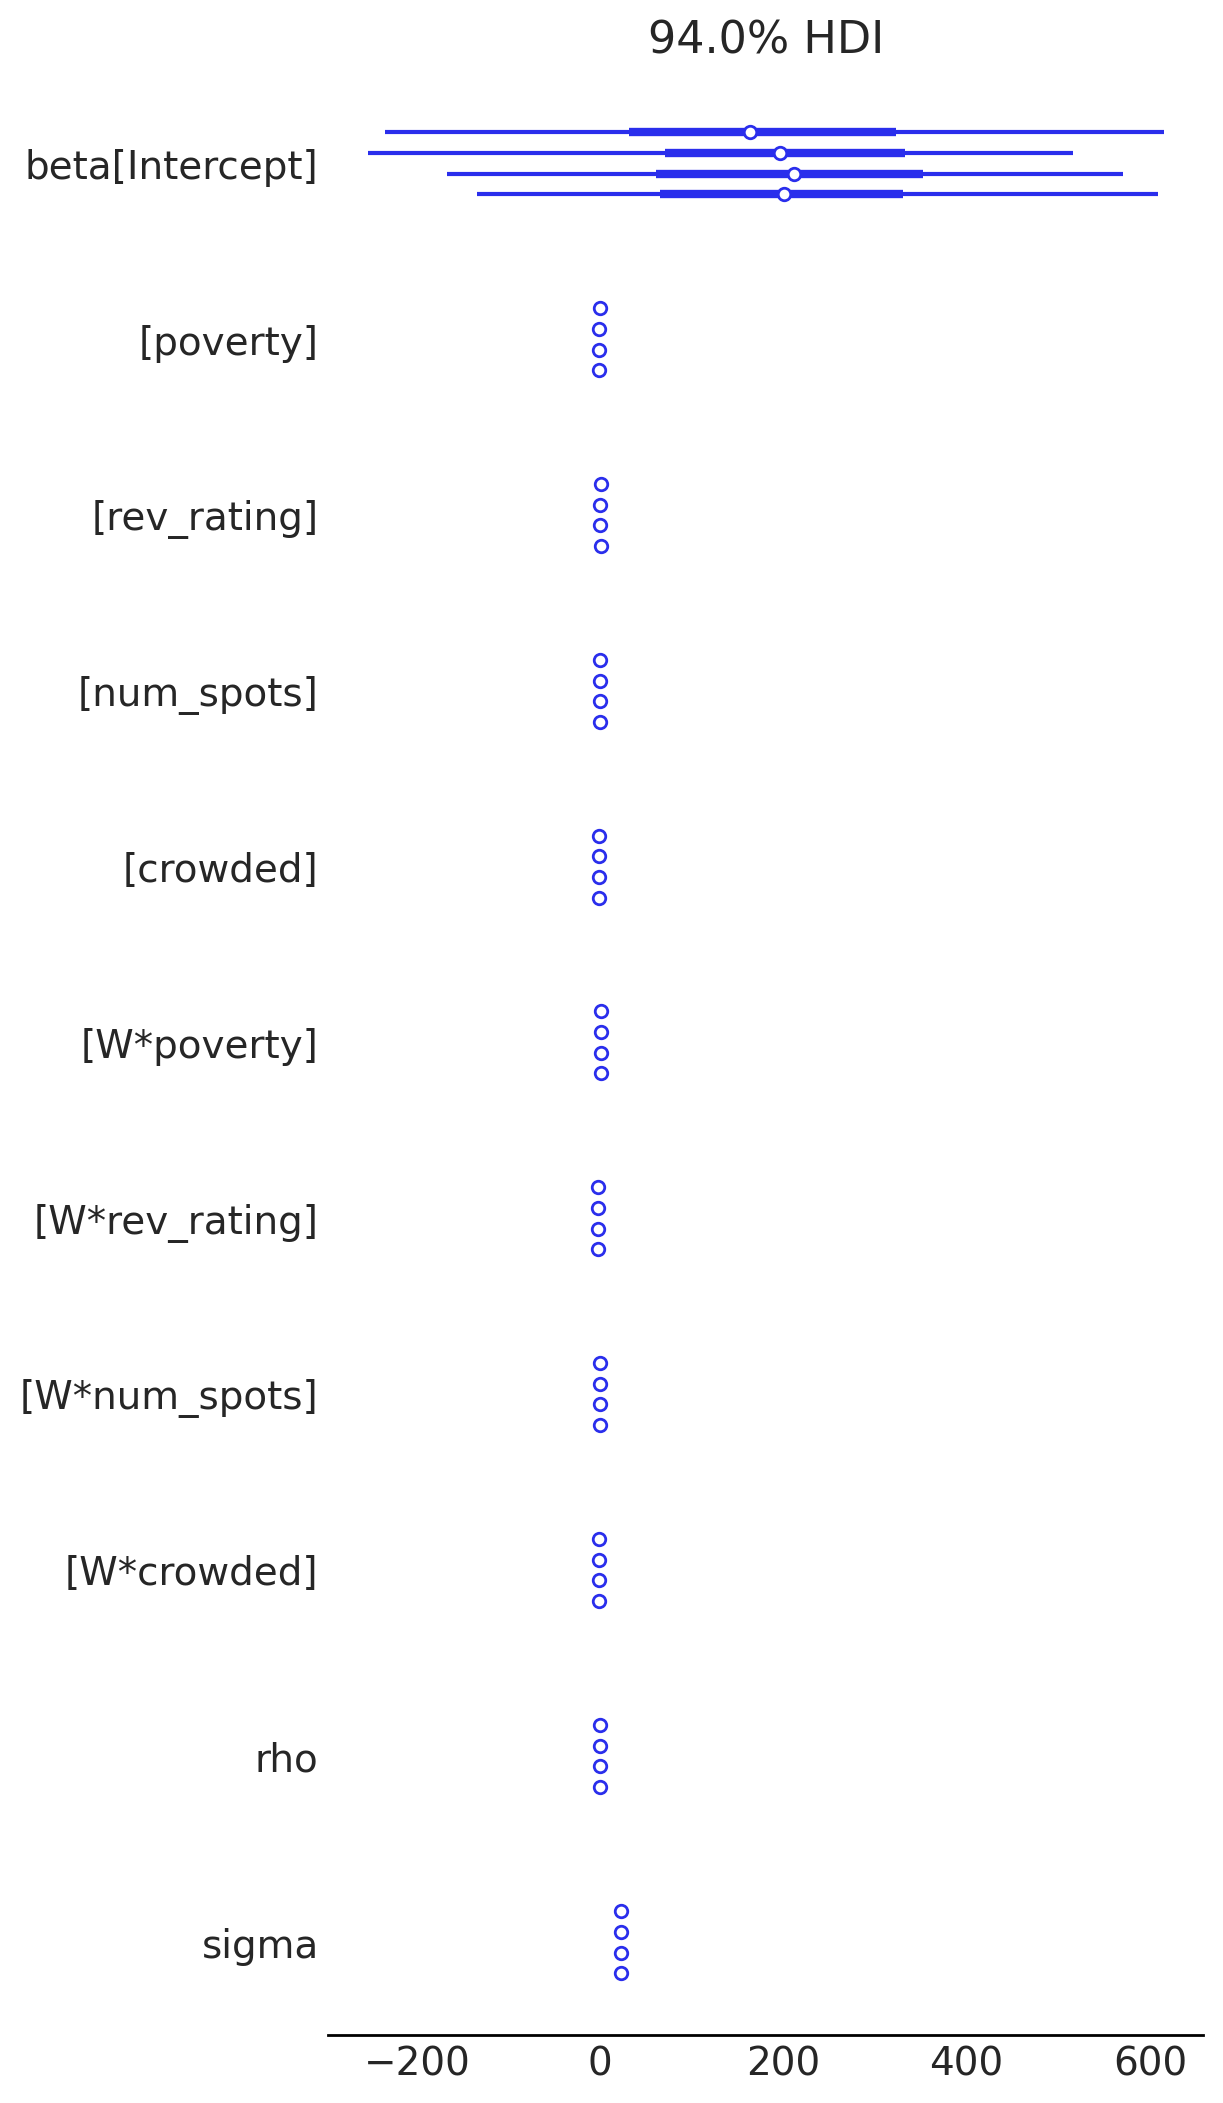

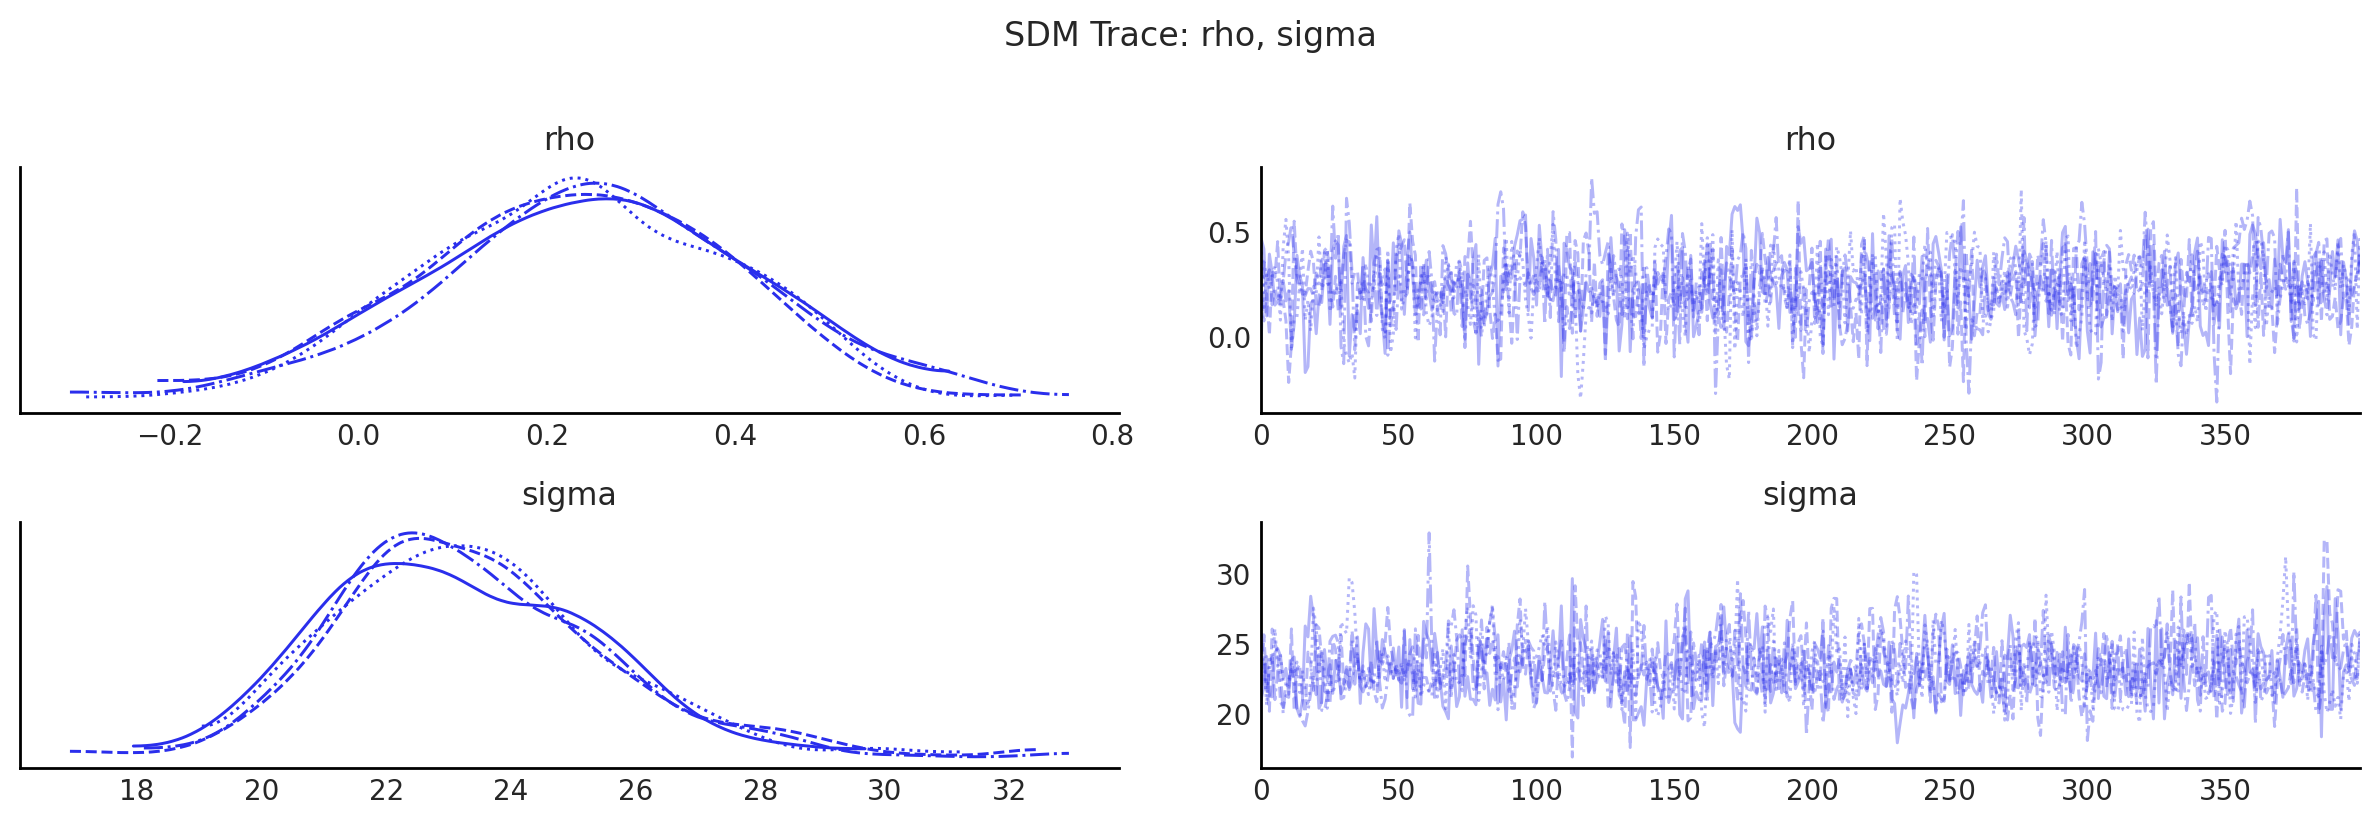

In [12]:
az.plot_forest(idata_sdm)
display(diagnostics_table(idata_sdm, ["rho", "beta", "sigma"]))
show_trace(idata_sdm, ["rho", "sigma"], "SDM Trace: rho, sigma")

## 5) SDEM: SLX + Spatial Error

Model:

$$
y = X\beta + WX\theta + u, \quad u = \lambda Wu + \epsilon
$$

Interpretation:
- Neighbor covariates matter directly (through $WX$),
- and unmodeled shocks are spatially correlated (through $u$).

In [13]:
sdem, idata_sdem, summary_sdem, effects_sdem = fit_and_report(
    SDEM,
    formula="price_pp ~ poverty + rev_rating + num_spots + crowded",
    data=gdf,
    W=W,
)
display(summary_sdem)
display(effects_sdem)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam, beta, sigma]
Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 23 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,247.886,239.575,-187.553,712.221,11.203,7.546,457.829,580.463,1.012
poverty,-0.655,0.431,-1.459,0.143,0.014,0.009,995.997,1144.104,1.001
rev_rating,0.241,0.956,-1.415,2.251,0.042,0.025,532.440,874.740,1.007
num_spots,0.027,0.029,-0.024,0.084,0.001,0.001,1166.441,1003.528,1.004
crowded,-1.050,1.077,-2.911,1.014,0.033,0.024,1079.518,1103.108,1.000
W*poverty,0.965,0.704,-0.367,2.237,0.026,0.018,755.289,1013.225,1.001
W*rev_rating,-2.232,1.926,-5.979,1.240,0.082,0.062,560.603,755.881,1.011
W*num_spots,0.189,0.049,0.101,0.282,0.001,0.001,1125.419,1260.711,1.007
W*crowded,-1.679,1.877,-5.385,1.841,0.066,0.052,828.798,954.225,1.002
lam,0.330,0.186,-0.019,0.658,0.006,0.005,867.885,834.361,1.001


,feature,direct,indirect,total
0,poverty,-0.654916,0.965473,0.310557
1,rev_rating,0.241402,-2.231589,-1.990187
2,num_spots,0.026996,0.189160,0.216156
3,crowded,-1.050244,-1.679098,-2.729342


,mean,sd,ess_bulk,ess_tail,r_hat
lam,0.330,0.186,867.885,834.361,1.001
beta[Intercept],247.886,239.575,457.829,580.463,1.012
beta[poverty],-0.655,0.431,995.997,1144.104,1.001
beta[rev_rating],0.241,0.956,532.440,874.740,1.007
beta[num_spots],0.027,0.029,1166.441,1003.528,1.004
beta[crowded],-1.050,1.077,1079.518,1103.108,1.000
beta[W*poverty],0.965,0.704,755.289,1013.225,1.001
beta[W*rev_rating],-2.232,1.926,560.603,755.881,1.011
beta[W*num_spots],0.189,0.049,1125.419,1260.711,1.007
beta[W*crowded],-1.679,1.877,828.798,954.225,1.002


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_21366/3308626596.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


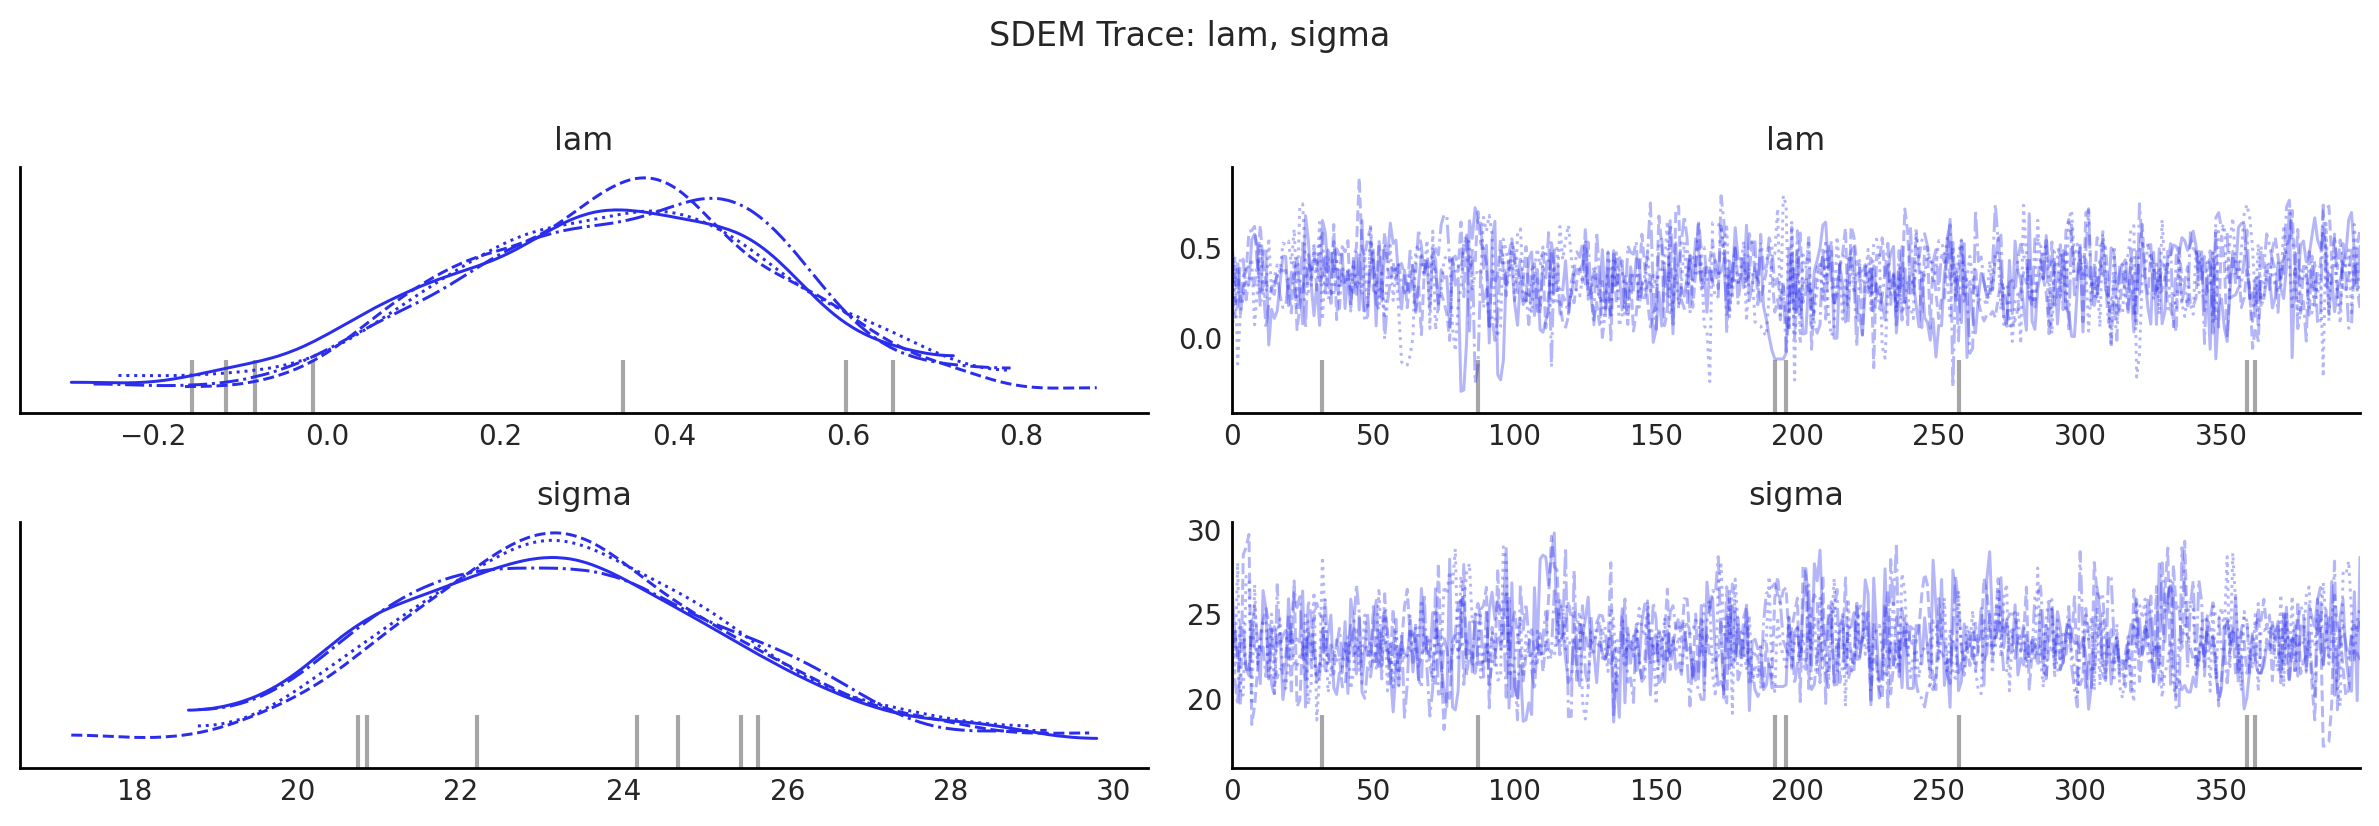

In [14]:
display(diagnostics_table(idata_sdem, ["lam", "beta", "sigma"]))
show_trace(idata_sdem, ["lam", "sigma"], "SDEM Trace: lam, sigma")

## Compare Spatial Parameters Across Models

This cell compares posterior means/intervals for the spatial scalar where present:
- `rho` in SAR/SDM
- `lam` in SEM/SDEM

In [15]:
def pull_scalar(idata, var_name):
    if var_name not in idata.posterior:
        return None
    vals = idata.posterior[var_name].values.reshape(-1)
    return {
        "mean": float(np.mean(vals)),
        "sd": float(np.std(vals)),
        "hdi_3%": float(np.quantile(vals, 0.03)),
        "hdi_97%": float(np.quantile(vals, 0.97)),
    }

rows = []
for name, idata, var in [
    ("SAR", idata_sar, "rho"),
    ("SEM", idata_sem, "lam"),
    ("SDM", idata_sdm, "rho"),
    ("SDEM", idata_sdem, "lam"),
]:
    stats = pull_scalar(idata, var)
    stats["model"] = name
    stats["parameter"] = var
    rows.append(stats)

spatial_param_table = pd.DataFrame(rows)[["model", "parameter", "mean", "sd", "hdi_3%", "hdi_97%"]]
display(spatial_param_table)

,model,parameter,mean,sd,hdi_3%,hdi_97%
0,SAR,rho,0.438409,0.138590,0.145681,0.694132
1,SEM,lam,0.524872,0.171888,0.176576,0.803262
2,SDM,rho,0.237799,0.167177,-0.082403,0.537888
3,SDEM,lam,0.330140,0.186031,-0.024042,0.655897


## Model Comparison: WAIC and LOO

We compare fitted models using information criteria from ArviZ.
Lower values are better on these scales.

Notes:
- These comparisons are only meaningful when models are fit to the same data.
- For robust results, increase `draws` and `tune` beyond this pedagogical setup.
- Some model formulations may not expose pointwise `log_likelihood`; those are skipped in the joint comparison and still reported in per-model attempts.

In [ ]:
idata_dict = {
    "SLX": idata_slx,
    "SAR": idata_sar,
    "SEM": idata_sem,
    "SDM": idata_sdm,
    "SDEM": idata_sdem,
}


def _has_loglik(idata):
    if "log_likelihood" not in idata.groups():
        return False
    return len(list(idata.log_likelihood.data_vars)) > 0


valid_for_compare = {name: idata for name, idata in idata_dict.items() if _has_loglik(idata)}
missing_loglik = [name for name, idata in idata_dict.items() if not _has_loglik(idata)]

if missing_loglik:
    print("Skipped (no log_likelihood group):", ", ".join(missing_loglik))

if len(valid_for_compare) < 2:
    print("Need at least two models with valid log_likelihood for WAIC/LOO compare.")
else:
    for ic in ("waic", "loo"):
        try:
            cmp = az.compare(valid_for_compare, ic=ic, method="BB-pseudo-BMA")
            print(f"{ic.upper()} comparison")
            display(cmp)
        except Exception as e:
            print(f"{ic.upper()} comparison not available: {type(e).__name__}: {e}")

# Always provide per-model IC attempts so the cell remains informative.
rows = []
for name, idata in idata_dict.items():
    row = {"model": name}

    try:
        waic_res = az.waic(idata)
        row["elpd_waic"] = float(waic_res.elpd_waic)
        row["p_waic"] = float(waic_res.p_waic)
    except Exception as e:
        row["elpd_waic"] = np.nan
        row["p_waic"] = np.nan
        row["waic_error"] = str(e).split("\n", 1)[0]

    try:
        loo_res = az.loo(idata)
        row["elpd_loo"] = float(loo_res.elpd_loo)
        row["p_loo"] = float(loo_res.p_loo)
    except Exception as e:
        row["elpd_loo"] = np.nan
        row["p_loo"] = np.nan
        row["loo_error"] = str(e).split("\n", 1)[0]

    rows.append(row)

ic_table = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(ic_table)

WAIC comparison not available: Encountered error in ELPD computation of compare.
LOO comparison not available: Encountered error in ELPD computation of compare.


## MATLAB-Style Residual Diagnostics (Per Model)

This section mirrors the MATLAB reference diagnostics module:
- `rdiagnose`-style influence and outlier diagnostics
- Breusch-Pagan heteroskedasticity test (`bpagan`)
- ARCH test (`arch`)
- Ljung-Box residual autocorrelation test (`qstat2`)

Interpretation quick guide:
- Smaller p-values for BPagan/ARCH/Ljung-Box suggest diagnostics concerns.
- Outlier counters are threshold-based candidate flags, not automatic exclusions.

In [17]:
pd.DataFrame(slx.spatial_effects())

,direct,indirect,total,feature_names
0,-0.680787,0.018101,-0.662686,poverty
1,0.353139,-0.024935,0.328205,rev_rating
2,0.019847,0.003011,0.022858,num_spots
3,-0.956494,-0.024075,-0.980569,crowded


In [18]:
models = {
    "SLX": slx,
    "SAR": sar,
    "SEM": sem,
    "SDM": sdm,
    "SDEM": sdem,
}

rows = []
for name, m in models.items():
    try:
        het = m.heteroskedasticity_diagnostics(arch_lags=[1, 2, 4])
        ac = m.autocorrelation_diagnostics(lags=[1, 2, 4])
        out = m.outlier_diagnostics()
    
        bp = het["bpagan"]
        arch = het["arch"]
    
        # Keep one compact row per model for quick pedagogical comparison.
        rows.append({
            "model": name,
            "bpagan_lm": float(bp["lm"]),
            "bpagan_p": float(bp["prob"]),
            "arch_lag4_stat": float(arch["archstat"][-1]),
            "arch_lag4_p": float(arch["pval"][-1]),
            "lb_lag4_q": float(ac["qstat"][-1]),
            "lb_lag4_p": float(ac["pval"][-1]),
            "n_leverage_flags": int(len(out["leverage_idx"])),
            "n_rstudent_flags": int(len(out["rstudent_idx"])),
            "n_dffit_flags": int(len(out["dffit_idx"])),
            "n_dfbeta_flags": int(out["dfbeta_idx"].shape[0]),
        })
    except:
        print(f'{name} failed')

diag_summary = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(diag_summary)

# Optional deep dive for one model
example = "SAR"
rd = models[example].regression_diagnostics()
print(f"Detailed rdiagnose-style outputs available for {example}:", sorted(rd.keys()))

SLX failed


,model,bpagan_lm,bpagan_p,arch_lag4_stat,arch_lag4_p,lb_lag4_q,lb_lag4_p,n_leverage_flags,n_rstudent_flags,n_dffit_flags,n_dfbeta_flags
0,SAR,10.962109,0.026993,2.555340,0.634754,1.998618,0.736013,7,3,7,21
1,SDEM,13.807305,0.007936,3.403914,0.492638,2.740587,0.602131,7,4,7,20
2,SDM,14.176297,0.006753,3.462970,0.483531,1.953504,0.744311,7,4,6,18
3,SEM,6.490607,0.165383,2.312777,0.678444,3.222309,0.521335,7,4,4,22


Detailed rdiagnose-style outputs available for SAR: ['cookd', 'dfbeta', 'dffit', 'hatdi', 'meth', 'press', 'pstat', 'resid', 'rstud', 'stdr', 'stud']


In [19]:
pd.DataFrame(sar.heteroskedasticity_diagnostics())

,bpagan,arch
meth,bpagan,arch
lm,10.962109,NaN
dof,4,NaN
prob,0.026993,NaN
lags,NaN,[5]
archstat,NaN,[3.3412949438168145]
pval,NaN,[0.6475256218186107]


## Matrix-Mode API Example (Optional)

The package also supports direct matrix inputs. This is useful if your design matrix is already engineered.

In [20]:
y = gdf[ycol]
X = gdf[xcols]

sar_matrix = SAR(y=y, X=X, W=W)
idata_sar_matrix = sar_matrix.fit(draws=200, tune=200, chains=2, random_seed=7, progressbar=False)
display(sar_matrix.summary(round_to=3))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
poverty,0.010,0.298,-0.504,0.629,0.018,0.012,285.648,229.906,1.007
rev_rating,0.461,0.109,0.247,0.642,0.008,0.005,191.547,237.062,1.000
num_spots,0.078,0.025,0.030,0.123,0.002,0.001,287.828,268.198,1.008
crowded,-1.684,0.900,-3.131,0.269,0.064,0.050,200.435,235.060,1.026
rho,0.438,0.128,0.174,0.648,0.009,0.006,198.066,173.442,1.002
sigma,24.291,2.249,20.587,28.654,0.129,0.160,307.305,224.157,1.012


## Notes for Real Analyses

- Increase `draws` and `tune` substantially (for example, 2000+ each).
- Inspect convergence diagnostics (`r_hat`, ESS, trace plots).
- Compare models with posterior predictive checks and information criteria.
- Consider prior sensitivity checks for spatial parameters (`rho`, `lam`).